# Лабораторная работа 11

## Цель
Построить **прогноз на 8 месяцев** с помощью регрессионной модели и метода сезонной индикации и сравнить метрики с другими моделями, изученными ранее

### Вариант 1
Коэффициент загрузки гостиниц в процентах (Hotel Occupancy (in %))
Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения процента занятых номеров за один день. Усреднение по отелям и по дням месяца
Данные расположены в столбце x1 файла Chicago_hotels.csv

**Период наблюдений:** январь 1994 — апрель 2003. **Прогноз:** май — декабрь 2003

ARIMA — это аббревиатура: AR (авторегрессия) + I (интегрирование) + MA (скользящее среднее). Параметры записываются как ARIMA(p, d, q)

**AR(p)** — авторегрессия. Идея: текущее значение ряда зависит от его прошлых значений. Например, AR(2) означает, что сегодняшнее значение это взвешенная сумма двух предыдущих плюс случайный шум

**MA(q)** — скользящее среднее. Здесь текущее значение зависит не от прошлых значений ряда, а от прошлых ошибок прогноза. Т.е. как будто модель помнит насколько она ошиблась в прошлый раз и делает поправку

**I(d)** — интегрирование. Это просто количество раз, которое мы дифференцируем ряд, чтобы сделать его стационарным. d=1 означает, что мы работаем не с самим рядом, а с приростами

Для корректной работы ARIMA временной ряд должен быть стационарным.

Стационарный ряд обладает:
- постоянным средним,
- постоянной дисперсией,
- отсутствием выраженного тренда.

SARIMA (Seasonal AutoRegressive Integrated Moving Average) — расширение модели ARIMA, которое учитывает сезонность временного ряда.

Модель применяется для данных, где наблюдаются повторяющиеся циклы (например, сезонные колебания по месяцам или кварталам).

Модель обозначается как:
SARIMA(p, d, q)(P, D, Q, s), где:

- **p** — порядок несезонной авторегрессии;
- **d** — порядок несезонного дифференцирования;
- **q** — порядок несезонного скользящего среднего;
- **P** — сезонная авторегрессия;
- **D** — сезонное дифференцирование;
- **Q** — сезонное скользящее среднее;
- **s** — длина сезонного периода (в данном случае s = 12, так как данные месячные).

Главное отличие SARIMA от ARIMA заключается в учёте сезонной структуры ряда, что позволяет более точно моделировать данные с выраженной периодичностью.

SARIMA также требует стационарности ряда, как и ARIMA, но дополнительно учитывает сезонную стационарность.

AUTO ARIMA — автоматизированный метод подбора параметров модели ARIMA (или SARIMA), реализованный в библиотеке pmdarima.

Данный метод автоматически подбирает оптимальные значения параметров p, d, q (и при необходимости сезонных P, D, Q) на основе критериев качества модели, таких как AIC (Akaike Information Criterion).

Основные особенности AUTO ARIMA:

- автоматически определяет степень дифференцирования d;
- перебирает различные комбинации параметров модели;
- выбирает наилучшую модель по минимальному значению AIC;
- может учитывать сезонность при параметре seasonal=True.

Модель снижает необходимость ручного подбора параметров и ускоряет процесс построения прогноза.

В результате AUTO ARIMA возвращает оптимальную модель ARIMA/SARIMA, которая наилучшим образом описывает временной ряд по выбранному критерию качества.

### Импорты

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools


from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

In [2]:
DATA_PATH = "data.csv"

raw = pd.read_csv("data.csv", sep=";", encoding="utf-8")
raw["x1"] = pd.to_numeric(raw["x1"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
raw = raw.dropna(subset=["x1"]).copy()

raw["date"] = pd.to_datetime(
    raw["date1"].astype(str) + " " + raw["date2"].astype(str),
    format="%B %Y",
    errors="coerce",
)
raw = raw.dropna(subset=["date"]).sort_values("date")
series = raw.set_index("date")["x1"].asfreq("MS")  # начало месяца

print(f"Число наблюдений: {len(series)}")
print(f"С {series.index.min().date()} по {series.index.max().date()}")
series.head()

Число наблюдений: 112
С 1994-01-01 по 2003-04-01


date
1994-01-01    44.3
1994-02-01    54.7
1994-03-01    61.9
1994-04-01    69.1
1994-05-01    70.8
Freq: MS, Name: x1, dtype: float64

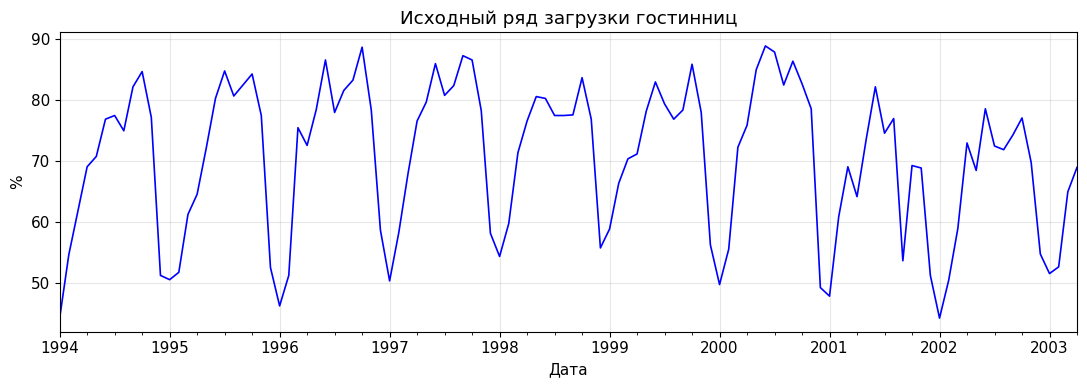

In [6]:
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["font.size"] = 11

fig, ax = plt.subplots()
series.plot(ax=ax, color="blue", linewidth=1.2)
ax.set_title("Исходный ряд загрузки гостинниц")
ax.set_xlabel("Дата")
ax.set_ylabel("%")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Тест на стационарность

Для проверки стационарности используется тест Дики-Фуллера (ADF-test)

**H0:** ряд нестационарен

**H1:** ряд стационарен

----
если **p-value < 0.05** → отвергаем H0 → ряд считается стационарным  
если **p-value ≥ 0.05** → нет оснований отвергнуть H0 → ряд нестационарен 

In [7]:
adf_orig = adfuller(series)
print(f"ADF исходный ряд:    stat={adf_orig[0]:.3f}, p={adf_orig[1]:.4f}")


adf_diff1 = adfuller(np.diff(series, 1))
print(f"ADF 1-я разность:    stat={adf_diff1[0]:.3f}, p={adf_diff1[1]:.10f}")

ADF исходный ряд:    stat=-1.259, p=0.6476
ADF 1-я разность:    stat=-5.665, p=0.0000009201


Видно, что после 1 дифференцирования ряд становится стационарным, таким образом останавливаемся на параметре d = 1

In [8]:
series_diff1 = np.diff(series, n=1)

### ARIMA

#### ACF/PACF дифференцированного ряда

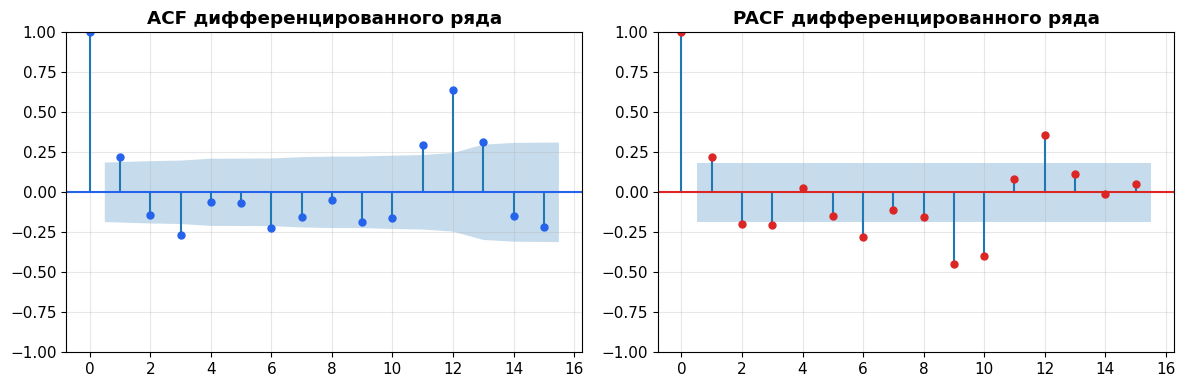

In [9]:
# ACF: если резко обрывается на лаге q → признак MA(q)
# PACF: если резко обрывается на лаге p → признак AR(p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_diff1, lags=15, ax=axes[0], color='#2563eb', alpha=0.05)
axes[0].set_title('ACF дифференцированного ряда', fontweight='bold')
axes[0].grid(True, alpha=0.3)


plot_pacf(series_diff1, lags=15, ax=axes[1], color='#dc2626', alpha=0.05)
axes[1].set_title('PACF дифференцированного ряда', fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

#### Перебор параметров

Для повышения точности модели используется перебор параметров p и q с оценкой качества по информационному критерию AIC (Akaike Information Criterion).

- Чем меньше значение AIC, тем лучше модель описывает данные
- Перебор позволяет выбрать наиболее оптимальную комбинацию параметров

In [11]:
# AIC штрафует за сложность модели, BIC штрафует сильнее
results = []
for p in range(0, 4):
    for d in [1]:
        for q in range(0, 4):
            try:
                m = ARIMA(series, order=(p, d, q)).fit()
                results.append({'order': (p, d, q), 'aic': round(m.aic, 2),
                                 'bic': round(m.bic, 2)})
            except Exception:
                pass

results_df = pd.DataFrame(results).sort_values('aic')
print("Топ-5 моделей")
print(results_df.head(5).to_string(index=False))

Топ-5 моделей
    order    aic    bic
(2, 1, 2) 774.92 788.47
(3, 1, 3) 781.13 800.10
(2, 1, 1) 785.31 796.15
(1, 1, 3) 786.21 799.76
(2, 1, 3) 787.22 803.47


In [27]:
best_order = (2, 1, 2)

#### Построение модели

In [28]:
print(f"\nПостроение модели ARIMA{best_order}")

best_model = ARIMA(series, order=best_order)
fitted_best = best_model.fit()

print(f"\nПараметры модели:")
print(fitted_best.summary())


Построение модели ARIMA(2, 1, 2)

Параметры модели:
                               SARIMAX Results                                
Dep. Variable:                     x1   No. Observations:                  112
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -382.462
Date:                Thu, 28 May 2026   AIC                            774.925
Time:                        12:13:54   BIC                            788.472
Sample:                    01-01-1994   HQIC                           780.421
                         - 04-01-2003                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.6220      0.066     24.427      0.000       1.492       1.752
ar.L2         -0.8858      0.066    -13.453      0.000      -1.015      -0.757

#### Оценка качества модели

In [39]:
# Прогноз на обучающей выборке
fitted_values = fitted_best.fittedvalues
train_series = series[fitted_values.index]

mae = mean_absolute_error(train_series, fitted_values)
rmse = np.sqrt(mean_squared_error(train_series, fitted_values))
mape = np.mean(np.abs((train_series - fitted_values) / train_series)) * 100

print(f"Метрики на обучающей выборке:")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAPE = {mape:.2f}%")

Метрики на обучающей выборке:
MAE  = 6.0017
RMSE = 8.6241
MAPE = 9.35%


#### Прогноз на 8 месяцев

In [30]:
horizon = 8
forecast = fitted_best.forecast(steps=horizon)

# Даты прогноза
future_dates = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=horizon,
    freq='MS'
)

forecast_series = pd.Series(forecast.values, index=future_dates)

# Доверительные интервалы
forecast_result = fitted_best.get_forecast(steps=horizon)
confidence_intervals = forecast_result.conf_int(alpha=0.05)
ci_lower = confidence_intervals.iloc[:, 0]
ci_upper = confidence_intervals.iloc[:, 1]

# Таблица прогноза
print("\n=== ПРОГНОЗ НА 8 МЕСЯЦЕВ (ARIMA) ===")
forecast_table = pd.DataFrame({
    'Дата': forecast_series.index.strftime('%B %Y'),
    'Прогноз загрузки (%)': forecast_series.values.round(2),
    'Нижняя граница (95%)': ci_lower.values.round(2),
    'Верхняя граница (95%)': ci_upper.values.round(2)
})
print(forecast_table.to_string(index=False))


=== ПРОГНОЗ НА 8 МЕСЯЦЕВ (ARIMA) ===
          Дата  Прогноз загрузки (%)  Нижняя граница (95%)  Верхняя граница (95%)
      May 2003                 76.15                 61.52                  90.78
     June 2003                 80.95                 62.20                  99.70
     July 2003                 82.41                 62.31                 102.50
   August 2003                 80.52                 60.27                 100.76
September 2003                 76.16                 55.88                  96.44
  October 2003                 70.77                 50.28                  91.27
 November 2003                 65.89                 45.23                  86.55
 December 2003                 62.74                 42.07                  83.40


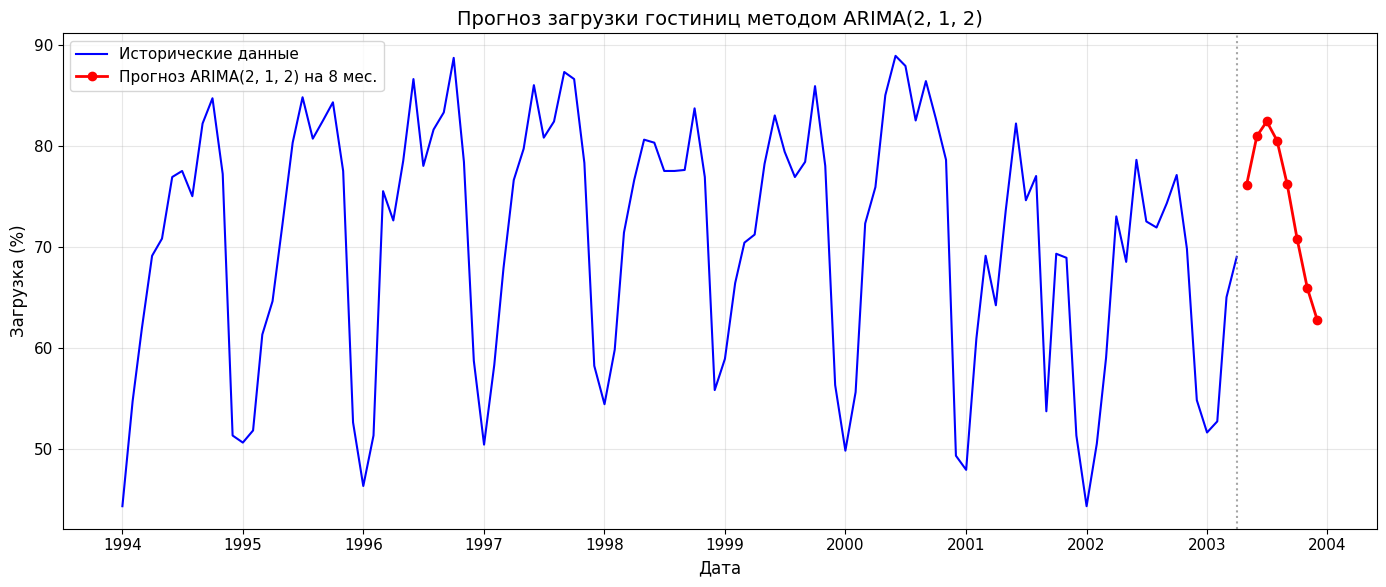

In [31]:
plt.figure(figsize=(14, 6))

# Исходные данные
plt.plot(series.index, series.values, 'b-', linewidth=1.5, label='Исторические данные')

# Прогноз
plt.plot(forecast_series.index, forecast_series.values, 'r-o', markersize=6, linewidth=2,
         label=f'Прогноз ARIMA{best_order} на {horizon} мес.')

# Вертикальная линия - начало прогноза
plt.axvline(x=series.index[-1], color='gray', linestyle=':', linewidth=1.5, alpha=0.7)

plt.title(f'Прогноз загрузки гостиниц методом ARIMA{best_order}', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Загрузка (%)', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### SARIMA

In [32]:
# Подбор параметров SARIMA
# seasonal_order = (P, D, Q, S)
# S = 12, так как данные месячные

best_sarima_aic = np.inf
best_sarima_order = None
best_seasonal_order = None

for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 2):

                try:
                    model = SARIMAX(
                        series,
                        order=(p, d, q),
                        seasonal_order=(P, 1, Q, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )

                    result = model.fit(disp=False)

                    if result.aic < best_sarima_aic:
                        best_sarima_aic = result.aic
                        best_sarima_order = (p, d, q)
                        best_seasonal_order = (P, 1, Q, 12)

                    print(
                        f"SARIMA({p},{d},{q})x({P},1,{Q},12)"
                        f" -> AIC={result.aic:.2f}"
                    )

                except:
                    continue

print("\nЛучшая SARIMA модель:")
print("order =", best_sarima_order)
print("seasonal_order =", best_seasonal_order)
print("AIC =", best_sarima_aic)

SARIMA(0,1,0)x(0,1,0,12) -> AIC=670.30
SARIMA(0,1,0)x(0,1,1,12) -> AIC=546.06
SARIMA(0,1,0)x(1,1,0,12) -> AIC=568.65
SARIMA(0,1,0)x(1,1,1,12) -> AIC=547.56
SARIMA(0,1,1)x(0,1,0,12) -> AIC=638.93
SARIMA(0,1,1)x(0,1,1,12) -> AIC=516.04
SARIMA(0,1,1)x(1,1,0,12) -> AIC=545.93
SARIMA(0,1,1)x(1,1,1,12) -> AIC=519.80
SARIMA(0,1,2)x(0,1,0,12) -> AIC=632.98
SARIMA(0,1,2)x(0,1,1,12) -> AIC=513.14
SARIMA(0,1,2)x(1,1,0,12) -> AIC=547.16
SARIMA(0,1,2)x(1,1,1,12) -> AIC=514.25
SARIMA(1,1,0)x(0,1,0,12) -> AIC=656.04
SARIMA(1,1,0)x(0,1,1,12) -> AIC=535.90
SARIMA(1,1,0)x(1,1,0,12) -> AIC=547.50
SARIMA(1,1,0)x(1,1,1,12) -> AIC=539.06
SARIMA(1,1,1)x(0,1,0,12) -> AIC=637.80
SARIMA(1,1,1)x(0,1,1,12) -> AIC=515.07
SARIMA(1,1,1)x(1,1,0,12) -> AIC=541.14
SARIMA(1,1,1)x(1,1,1,12) -> AIC=518.66
SARIMA(1,1,2)x(0,1,0,12) -> AIC=632.27
SARIMA(1,1,2)x(0,1,1,12) -> AIC=513.30
SARIMA(1,1,2)x(1,1,0,12) -> AIC=541.73
SARIMA(1,1,2)x(1,1,1,12) -> AIC=515.07
SARIMA(2,1,0)x(0,1,0,12) -> AIC=649.47
SARIMA(2,1,0)x(0,1,1,12) 

#### Построение модели

In [34]:
sarima_model = SARIMAX(
    series,
    order=best_sarima_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                   x1   No. Observations:                  112
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 12)   Log Likelihood                -252.568
Date:                              Thu, 28 May 2026   AIC                            513.136
Time:                                      12:16:06   BIC                            522.859
Sample:                                  01-01-1994   HQIC                           517.045
                                       - 04-01-2003                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5653      0.171     -3.302      0.001      -0.901      -0.230
ma.L2         -0.12

#### Прогноз

In [35]:
forecast_sarima = sarima_fit.forecast(steps=8)

forecast_sarima.index = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=8,
    freq='MS'
)

print("\nПрогноз SARIMA:")
print(forecast_sarima)


Прогноз SARIMA:
2003-05-01    73.560477
2003-06-01    79.953281
2003-07-01    76.235864
2003-08-01    75.428434
2003-09-01    74.546150
2003-10-01    79.008207
2003-11-01    72.741550
2003-12-01    51.513763
Freq: MS, Name: predicted_mean, dtype: float64


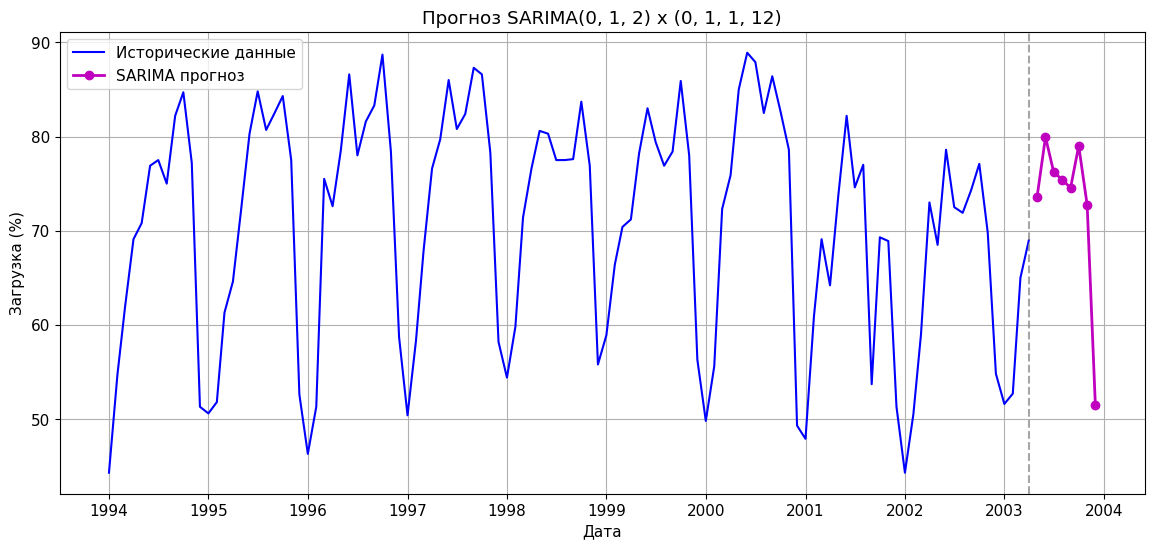

In [40]:
plt.figure(figsize=(14,6))

# Исторические данные
plt.plot(
    series.index,
    series.values,
    label='Исторические данные',
    color='blue',
    linewidth=1.5
)

# Прогноз SARIMA
plt.plot(
    forecast_sarima.index,
    forecast_sarima.values,
    'm-o',
    linewidth=2,
    markersize=6,
    label='SARIMA прогноз'
)

# Линия начала прогноза
plt.axvline(
    x=series.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

plt.title(
    f'Прогноз SARIMA{best_sarima_order} '
    f'x {best_seasonal_order}'
)

plt.xlabel('Дата')
plt.ylabel('Загрузка (%)')

plt.legend()
plt.grid(True)

plt.show()

#### Метрики

In [38]:
fitted_sarima = sarima_fit.fittedvalues

# выравниваем индексы
common_index = series.index.intersection(fitted_sarima.index)

actual_sarima = series.loc[common_index]
fitted_sarima = fitted_sarima.loc[common_index]

mae_sarima = mean_absolute_error(
    actual_sarima,
    fitted_sarima
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        actual_sarima,
        fitted_sarima
    )
)

mape_sarima = np.mean(
    np.abs(
        (actual_sarima - fitted_sarima)
        / actual_sarima
    )
) * 100

print("SARIMA")
print(f"MAE  = {mae_sarima:.4f}")
print(f"RMSE = {rmse_sarima:.4f}")
print(f"MAPE = {mape_sarima:.2f}%")

SARIMA
MAE  = 4.3901
RMSE = 7.5044
MAPE = 7.11%


### Auto ARIMA

In [41]:
# Автоматический подбор параметров
auto_model = auto_arima(
    series,
    seasonal=True,
    m=12,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=743.366, Time=0.34 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=881.692, Time=0.00 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=729.107, Time=0.15 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=780.220, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=1276.944, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=808.619, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[12] intercept   : AIC=inf, Time=0.50 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=709.095, Time=0.23 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=770.449, Time=0.08 sec
 ARIMA(1,0,0)(2,0,1)[12] intercept   : AIC=730.024, Time=0.45 sec
 ARIMA(1,0,0)(1,0,2)[12] intercept   : AIC=718.136, Time=0.45 sec
 ARIMA(1,0,0)(0,0,2)[12] intercept   : AIC=743.582, Time=0.25 sec
 ARIMA(1,0,0)(2,0,2)[12] intercept   : AIC=inf, Time=0.51 sec
 ARIMA(0,0,0)(1,0,1)[12] intercept   : AIC=745.526, Time=0.24 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : A

#### Прогноз

In [42]:
forecast_auto = auto_model.predict(n_periods=8)

forecast_auto = pd.Series(
    forecast_auto,
    index=pd.date_range(
        start=series.index[-1] + pd.DateOffset(months=1),
        periods=8,
        freq='MS'
    )
)

print("\nПрогноз AUTO ARIMA:")
print(forecast_auto)


Прогноз AUTO ARIMA:
2003-05-01    71.090375
2003-06-01    78.503238
2003-07-01    73.953001
2003-08-01    73.649250
2003-09-01    70.403605
2003-10-01    75.094078
2003-11-01    70.676992
2003-12-01    55.524381
Freq: MS, dtype: float64


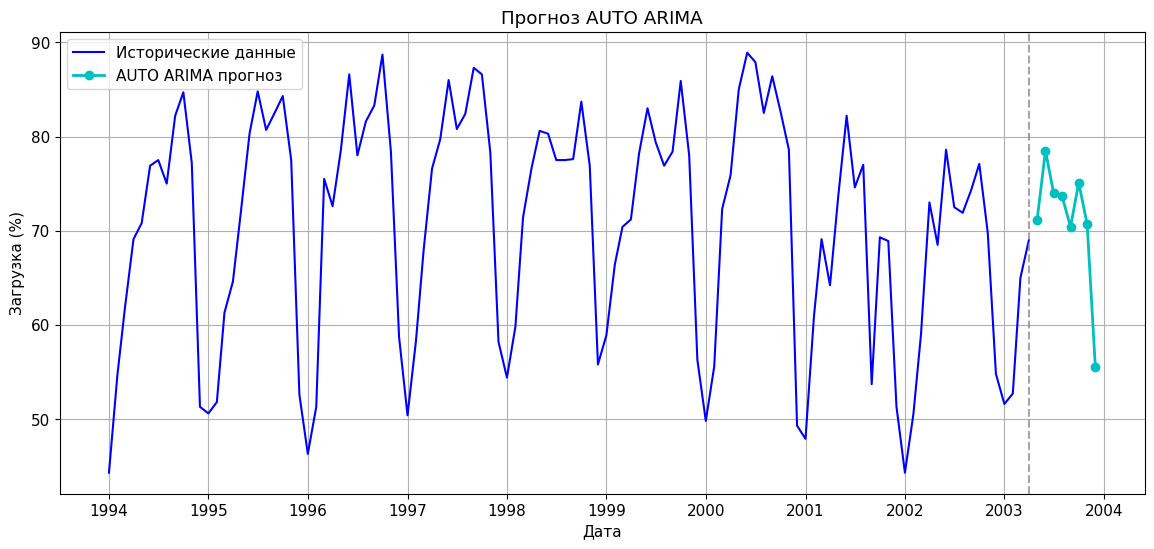

In [44]:
plt.figure(figsize=(14,6))

# Исторические данные
plt.plot(
    series.index,
    series.values,
    label='Исторические данные',
    color='blue',
    linewidth=1.5
)

# Прогноз AUTO ARIMA
plt.plot(
    forecast_auto.index,
    forecast_auto.values,
    'c-o',
    linewidth=2,
    markersize=6,
    label='AUTO ARIMA прогноз'
)

# Линия начала прогноза
plt.axvline(
    x=series.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

plt.title('Прогноз AUTO ARIMA')

plt.xlabel('Дата')
plt.ylabel('Загрузка (%)')

plt.legend()
plt.grid(True)

plt.show()


#### Метрики

In [45]:
fitted_auto = pd.Series(
    auto_model.predict_in_sample(),
    index=series.index
)

mae_auto = mean_absolute_error(
    series,
    fitted_auto
)

rmse_auto = np.sqrt(
    mean_squared_error(
        series,
        fitted_auto
    )
)

mape_auto = np.mean(
    np.abs(
        (series - fitted_auto)
        / series
    )
) * 100

print("AUTO ARIMA")
print(f"MAE  = {mae_auto:.4f}")
print(f"RMSE = {rmse_auto:.4f}")
print(f"MAPE = {mape_auto:.2f}%")

AUTO ARIMA
MAE  = 4.1573
RMSE = 5.7878
MAPE = 6.33%


### Авторегрессионная модель

In [46]:
ar_model = AutoReg(
    series,
    lags=12
)

ar_fit = ar_model.fit()

print(ar_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                     x1   No. Observations:                  112
Model:                    AutoReg(12)   Log Likelihood                -307.224
Method:               Conditional MLE   S.D. of innovations              5.224
Date:                Thu, 28 May 2026   AIC                            642.449
Time:                        12:21:25   BIC                            678.921
Sample:                    01-01-1995   HQIC                           657.210
                         - 04-01-2003                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.8890     11.275      0.877      0.380     -12.210      31.988
x1.L1          0.4845      0.095      5.080      0.000       0.298       0.671
x1.L2         -0.0349      0.099     -0.354      0.7

#### Прогноз

In [48]:
forecast_ar = ar_fit.predict(
    start=len(series),
    end=len(series)+7
)

# Даты прогноза
forecast_ar.index = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=8,
    freq='MS'
)

print("\nПрогноз AR:")
print(forecast_ar)


Прогноз AR:
2003-05-01    73.162209
2003-06-01    75.602983
2003-07-01    74.295040
2003-08-01    73.220750
2003-09-01    74.653814
2003-10-01    75.011636
2003-11-01    69.084888
2003-12-01    58.780338
Freq: MS, dtype: float64


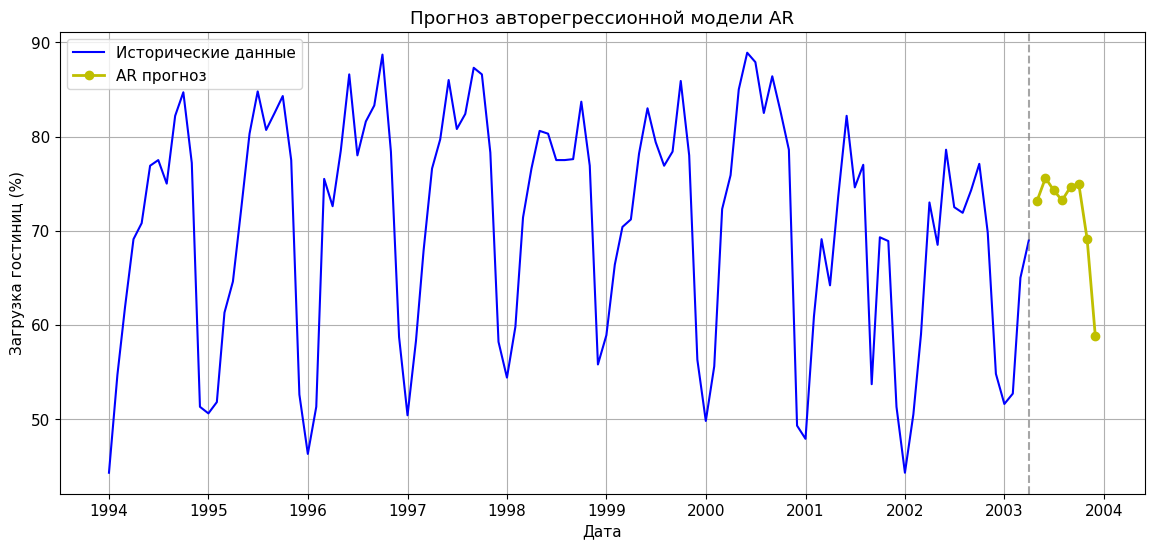

In [49]:
plt.figure(figsize=(14,6))

# Исторические данные
plt.plot(
    series.index,
    series.values,
    label='Исторические данные',
    color='blue',
    linewidth=1.5
)

# Прогноз AR
plt.plot(
    forecast_ar.index,
    forecast_ar.values,
    'y-o',
    linewidth=2,
    markersize=6,
    label='AR прогноз'
)

# Линия начала прогноза
plt.axvline(
    x=series.index[-1],
    color='gray',
    linestyle='--',
    alpha=0.7
)

plt.title('Прогноз авторегрессионной модели AR')

plt.xlabel('Дата')
plt.ylabel('Загрузка гостиниц (%)')

plt.legend()
plt.grid(True)

plt.show()

#### Метрики

In [50]:
# Предсказания на обучающей выборке
fitted_ar = ar_fit.fittedvalues

# Выравнивание индексов
actual_ar = series[len(series)-len(fitted_ar):]

# Метрики
mae_ar = mean_absolute_error(
    actual_ar,
    fitted_ar
)

rmse_ar = np.sqrt(
    mean_squared_error(
        actual_ar,
        fitted_ar
    )
)

mape_ar = np.mean(
    np.abs(
        (actual_ar - fitted_ar)
        / actual_ar
    )
) * 100

print("Авторегрессионная модель AR")

print(f"MAE  = {mae_ar:.4f}")
print(f"RMSE = {rmse_ar:.4f}")
print(f"MAPE = {mape_ar:.2f}%")

Авторегрессионная модель AR
MAE  = 3.8305
RMSE = 5.2242
MAPE = 5.77%


### Сезонная индикация

#### Прогноз

In [51]:
# Подготовка данных
df = pd.DataFrame({
    'y': series,
    'month_num': range(1, len(series) + 1),
    'month': series.index.month
})

# Сезонные дамми (drop_first=True чтобы избежать мультиколлинеарности)
dummies = pd.get_dummies(df['month'], prefix='m', drop_first=True)

# Финальный датафрейм для регрессии
X = pd.concat([df[['month_num']], dummies], axis=1)
y = df['y']

# Обучение модели
model = LinearRegression()
model.fit(X, y)

# Прогноз
horizon = 8

last_month_num = df['month_num'].iloc[-1]
last_month = series.index[-1].month

future_months_num = range(last_month_num + 1, last_month_num + 1 + horizon)
future_months = [(last_month + i - 1) % 12 + 1 for i in range(1, horizon + 1)]

future_dummies = pd.get_dummies(
    pd.Series(future_months),
    prefix='m'
)

# Выравниваем колонки с обучающими данными
future_dummies = future_dummies.reindex(columns=dummies.columns, fill_value=0)

X_forecast = pd.concat([
    pd.DataFrame({'month_num': future_months_num}),
    future_dummies.reset_index(drop=True)
], axis=1)

forecast = model.predict(X_forecast)

# Даты прогноза
future_dates = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=horizon,
    freq='MS'
)

forecast_indicator = pd.Series(forecast, index=future_dates)

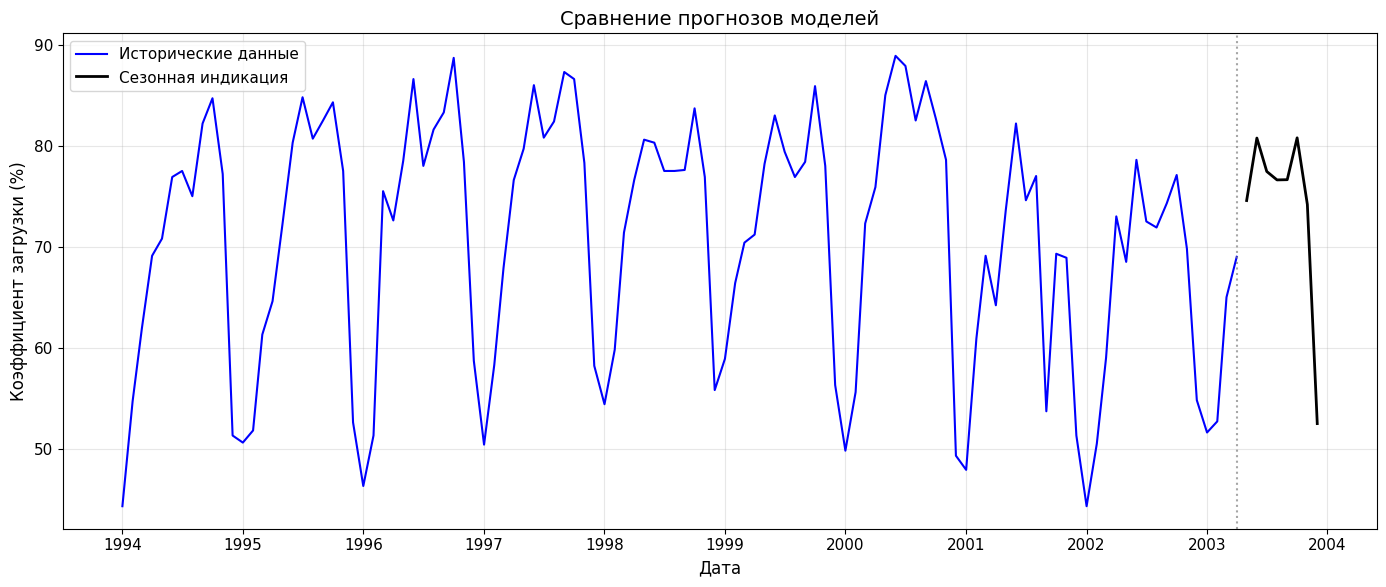

In [58]:
plt.figure(figsize=(14, 6))

# Исторические данные
plt.plot(
    series.index,
    series.values,
    color='blue',
    linewidth=1.5,
    label='Исторические данные'
)

# Прогноз: сезонная индикация
plt.plot(
    forecast_indicator.index,
    forecast_indicator.values,
    'black',
    linewidth=2,
    markersize=5,
    label='Сезонная индикация'
)

# Линия начала прогноза
plt.axvline(
    x=series.index[-1],
    color='gray',
    linestyle=':',
    linewidth=1.5,
    alpha=0.7
)

plt.title('Сравнение прогнозов моделей', fontsize=14)

plt.xlabel('Дата', fontsize=12)
plt.ylabel('Коэффициент загрузки (%)', fontsize=12)

plt.legend(loc='best')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Метрики

In [60]:
# Fitted values модели индикации
fitted_indicator = pd.Series(model.predict(X), index=series.index)

# Датафрейм для метрик
indicator_df = pd.DataFrame({
    'actual': series,
    'fitted': fitted_indicator
}).dropna()

# Метрики
mae_indicator = mean_absolute_error(
    indicator_df['actual'],
    indicator_df['fitted']
)

rmse_indicator = np.sqrt(
    mean_squared_error(
        indicator_df['actual'],
        indicator_df['fitted']
    )
)

mape_indicator = np.mean(
    np.abs(
        (indicator_df['actual'] - indicator_df['fitted'])
        / indicator_df['actual']
    )
) * 100

print("Сезонная индикация")

print(f"MAE  = {mae_indicator:.4f}")
print(f"RMSE = {rmse_indicator:.4f}")
print(f"MAPE = {mape_indicator:.2f}%")

Сезонная индикация
MAE  = 3.7514
RMSE = 4.9276
MAPE = 5.58%


### Экспоненциальное сглаживание

#### Прогноз

In [61]:
hw_model = ExponentialSmoothing(
    series,
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

hw_fit = hw_model.fit(optimized=True)

# Прогноз
forecast_hw = hw_fit.forecast(8)

# Индексы дат
forecast_hw.index = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=8,
    freq='MS'
)

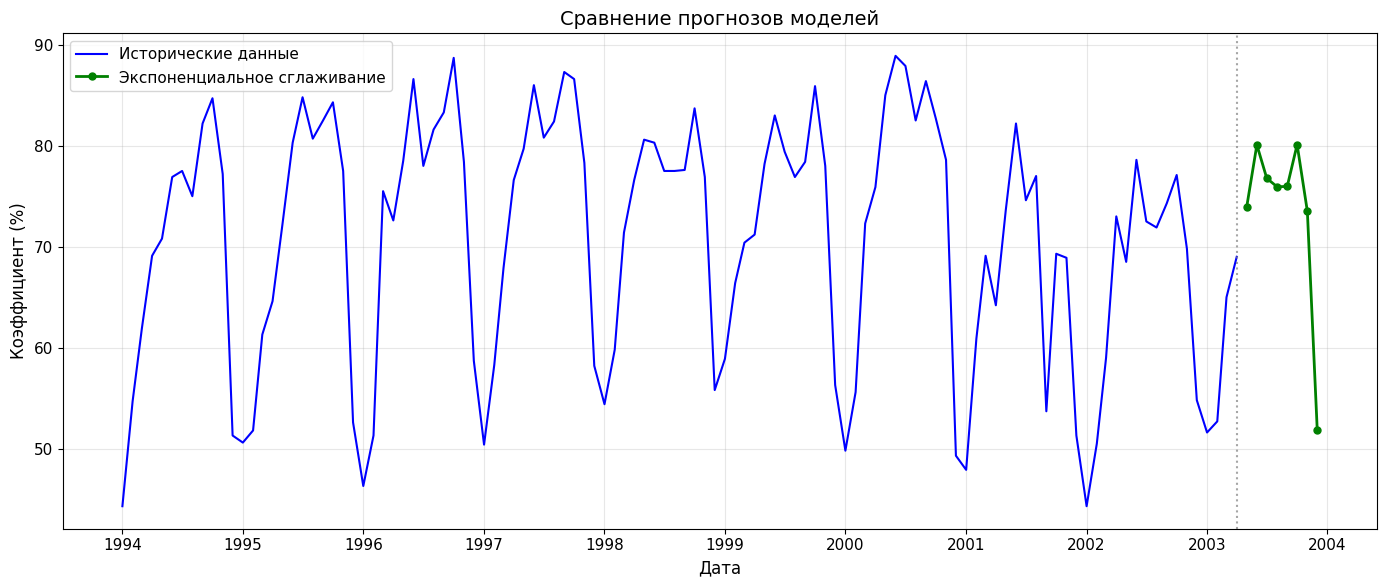

In [65]:
plt.figure(figsize=(14, 6))

# Исторические данные
plt.plot(
    series.index,
    series.values,
    color='blue',
    linewidth=1.5,
    label='Исторические данные'
)

# Прогноз: Экспоненциальное сглаживание
plt.plot(
    forecast_hw.index,
    forecast_hw.values,
    'g-o',
    linewidth=2,
    markersize=5,
    label='Экспоненциальное сглаживание'
)


# Линия начала прогноза
plt.axvline(
    x=series.index[-1],
    color='gray',
    linestyle=':',
    linewidth=1.5,
    alpha=0.7
)

plt.title('Сравнение прогнозов моделей', fontsize=14)

plt.xlabel('Дата', fontsize=12)
plt.ylabel('Коэффициент (%)', fontsize=12)

plt.legend(loc='best')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Метрики

In [67]:
fitted_hw = hw_fit.fittedvalues

mae_hw = mean_absolute_error(
    series,
    fitted_hw
)

rmse_hw = np.sqrt(
    mean_squared_error(
        series,
        fitted_hw
    )
)

mape_hw = np.mean(
    np.abs(
        (series - fitted_hw)
        / series
    )
) * 100

print("Экспоненциальное сглаживание")
print(f"MAE  = {mae_hw:.4f}")
print(f"RMSE = {rmse_hw:.4f}")
print(f"MAPE = {mape_hw:.2f}%")

Экспоненциальное сглаживание
MAE  = 2.8507
RMSE = 4.0861
MAPE = 4.31%


### Итоговое сравнение метрик

In [68]:
comparison = pd.DataFrame({

    'Модель': [
        'Сезонная индикация',
        'Экспоненциальное сглаживание',
        'ARIMA',
        'SARIMA',
        'AUTO ARIMA',
        'AR'
    ],

    'MAE': [
        mae_indicator,
        mae_hw,
        mae,
        mae_sarima,
        mae_auto,
        mae_ar
    ],

    'RMSE': [
        rmse_indicator,
        rmse_hw,
        rmse,
        rmse_sarima,
        rmse_auto,
        rmse_ar
    ],

    'MAPE (%)': [
        mape_indicator,
        mape_hw,
        mape,
        mape_sarima,
        mape_auto,
        mape_ar
    ]
})

comparison = comparison.round(4)

print(comparison)

                         Модель     MAE    RMSE  MAPE (%)
0            Сезонная индикация  3.7514  4.9276    5.5825
1  Экспоненциальное сглаживание  2.8507  4.0861    4.3084
2                         ARIMA  6.0017  8.6241    9.3474
3                        SARIMA  4.3901  7.5044    7.1148
4                    AUTO ARIMA  4.1573  5.7878    6.3341
5                            AR  3.8305  5.2242    5.7657


### Общий график прогнозов

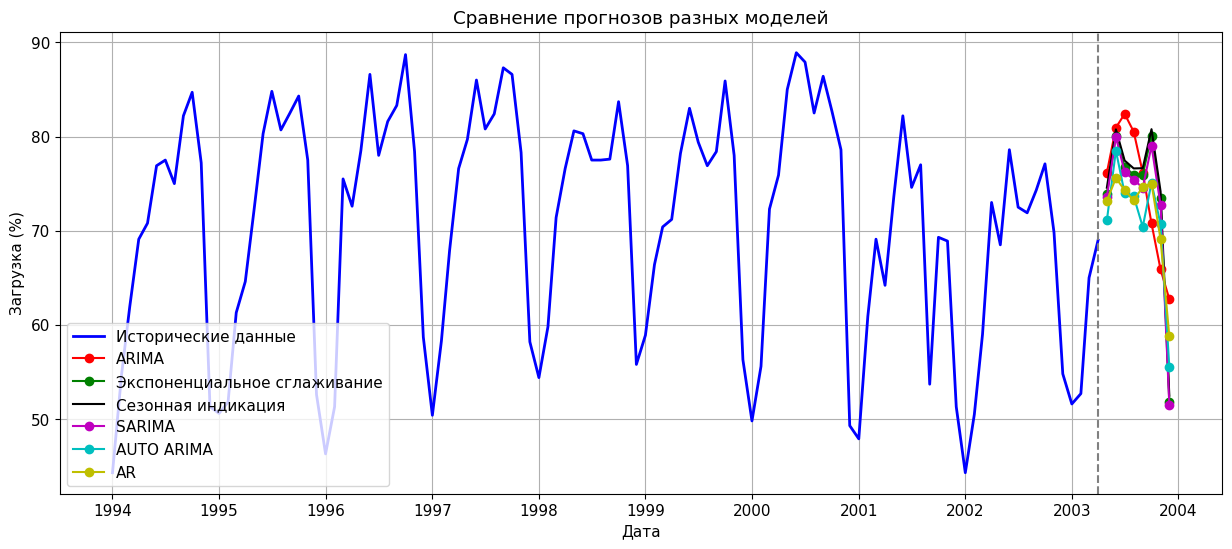

In [73]:
plt.figure(figsize=(15,6))

# Исторические данные
plt.plot(
    series.index,
    series.values,
    color='blue',
    linewidth=2,
    label='Исторические данные'
)

# ARIMA
plt.plot(
    forecast_series.index,
    forecast_series.values,
    'r-o',
    label='ARIMA'
)

# Holt-Winters
plt.plot(
    forecast_hw.index,
    forecast_hw.values,
    'g-o',
    label='Экспоненциальное сглаживание'
)

# Seasonal decomposition
plt.plot(
    forecast_indicator.index,
    forecast_indicator.values,
    'black',
    label='Сезонная индикация'
)

# SARIMA
plt.plot(
    forecast_sarima.index,
    forecast_sarima.values,
    'm-o',
    label='SARIMA'
)

# AUTO ARIMA
plt.plot(
    forecast_auto.index,
    forecast_auto.values,
    'c-o',
    label='AUTO ARIMA'
)

# Авторегрессионная модель AR
plt.plot(
    forecast_ar.index,
    forecast_ar.values,
    'y-o',
    label='AR'
)

plt.axvline(
    x=series.index[-1],
    color='gray',
    linestyle='--'
)

plt.title('Сравнение прогнозов разных моделей')
plt.xlabel('Дата')
plt.ylabel('Загрузка (%)')

plt.legend()
plt.grid(True)

plt.show()

### Вывод

По результатам сравнения моделей можно сделать вывод, что наилучшее качество прогнозирования продемонстрировал метод экспоненциального сглаживания. Для него были получены минимальные значения ошибок: MAE = 2.85, RMSE = 4.08 и MAPE = 4.3%. Это означает, что модель наиболее точно описывает структуру временного ряда и хорошо учитывает сезонные колебания загрузки гостиниц.

Модели сезонной индикации и авторегрессии также показали высокую точность прогнозирования. Значения метрик оказались близкими к экспоненциальному сглаживанию, что свидетельствует о хорошем качестве модели и способности эффективно учитывать тренд и сезонность временного ряда.

Модель AUTO ARIMA продемонстрировала лучшие результаты среди моделей семейства ARIMA. Автоматический подбор параметров позволил улучшить качество прогноза по сравнению с классической ARIMA и SARIMA

Модель SARIMA показала более точные результаты по сравнению с обычной ARIMA благодаря учёту сезонной компоненты ряда

Классическая модель ARIMA продемонстрировала наибольшие ошибки прогнозирования среди всех рассмотренных моделей. Это связано с тем, что стандартная ARIMA хуже справляется с выраженной сезонностью данных